# Chapter 1 — Exploratory Data Analysis (EDA)

**Buku:** *Practical Statistics for Data Scientists* (O'Reilly)   
**Chapter:** 1 — Exploratory Data Analysis

## Tujuan
Notebook ini mereproduksi konsep dan contoh pemrograman utama pada Chapter 1 menggunakan Python, sekaligus memberikan penjelasan teori dan interpretasi hasil.


## 1. Gambaran Umum Chapter

Exploratory Data Analysis (EDA) adalah tahap awal untuk memahami data sebelum analisis atau pemodelan dilakukan. Chapter ini menekankan penggunaan ringkasan statistik dan visualisasi untuk memahami:

- struktur dan tipe data,
- ukuran lokasi/pemusatan,
- ukuran variabilitas,
- distribusi data,
- data kategorikal dan biner,
- hubungan antarvariabel,
- serta hubungan dua atau lebih variabel.

Chapter juga memperkenalkan cara memilih ukuran statistik dan grafik yang sesuai dengan karakteristik data.

## 2. Structured Data dan Rectangular Data

### Structured Data
Data dapat berbentuk numerik atau kategorikal. Data numerik dapat bersifat **continuous** atau **discrete**, sedangkan data kategorikal dapat berupa **binary** atau **ordinal**.

### Rectangular Data
Bentuk data yang paling umum dalam data science adalah tabel dua dimensi:

- **baris** → record/observation,
- **kolom** → feature/variable.

Contoh data `state` pada chapter memiliki kolom `State`, `Population`, `Murder.Rate`, dan `Abbreviation`.

**Mengapa tipe data penting?** Karena tipe data memberi sinyal kepada software tentang bagaimana suatu variabel harus diproses.

In [1]:
# Instalasi library yang digunakan dalam reproduksi Chapter 1.
%pip -q install wquantiles

In [2]:
import io
import gzip
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import trim_mean
from statsmodels import robust
import wquantiles

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

# Dataset berasal dari code/data repository resmi buku edisi kedua.
BASE = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/"

def get_data(filename):
    path = DATA_DIR / filename
    if not path.exists():
        urllib.request.urlretrieve(BASE + filename, path)
    return path

print("Data directory:", DATA_DIR.resolve())

Data directory: /content/data


## 3. Dataset `state`: Estimates of Location

Chapter menggunakan data negara bagian Amerika Serikat untuk menunjukkan ukuran lokasi. Variabel utama yang digunakan:

- `Population` — jumlah penduduk,
- `Murder.Rate` — murder rate,
- `State` — nama negara bagian,
- `Abbreviation` — singkatan negara bagian.

Ukuran lokasi membantu menjawab pertanyaan: **di sekitar nilai berapa data berpusat?**

In [3]:
state = pd.read_csv(get_data("state.csv"))
state.head(8)

,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.7,AL
1,Alaska,710231,5.6,AK
2,Arizona,6392017,4.7,AZ
3,Arkansas,2915918,5.6,AR
4,California,37253956,4.4,CA
5,Colorado,5029196,2.8,CO
6,Connecticut,3574097,2.4,CT
7,Delaware,897934,5.8,DE


### 3.1 Mean

Mean/rata-rata adalah jumlah seluruh nilai dibagi jumlah observasi:

\[
\bar{x} = \frac{\sum_{i=1}^{n}x_i}{n}
\]

Mean mudah dipahami, tetapi sensitif terhadap nilai ekstrem.

In [4]:
mean_population = state["Population"].mean()
trimmed_population = trim_mean(state["Population"], proportiontocut=0.10)
median_population = state["Population"].median()

print("Mean population   :", mean_population)
print("10% trimmed mean  :", trimmed_population)
print("Median population :", median_population)

Mean population   : 6162876.3
10% trimmed mean  : 4783697.125
Median population : 4436369.5


### Interpretasi

Pada data `state`, mean populasi lebih besar daripada median karena beberapa negara bagian mempunyai populasi yang sangat besar. Trimmed mean membuang 10% nilai terendah dan 10% nilai tertinggi sehingga pengaruh nilai ekstrem berkurang.

Nilai dari notebook sumber yang menjadi pembanding adalah sekitar:

- mean = **6,162,876.3**
- 10% trimmed mean = **4,783,697.125**
- median = **4,436,369.5**

### 3.2 Weighted Mean dan Weighted Median

Weighted mean memberi bobot berbeda pada observasi:

\[
\bar{x}_w =
\frac{\sum_i w_i x_i}{\sum_i w_i}
\]

Dalam contoh murder rate, populasi digunakan sebagai bobot sehingga negara bagian dengan populasi lebih besar mempunyai pengaruh lebih besar terhadap nilai keseluruhan.

In [5]:
mean_murder = state["Murder.Rate"].mean()
weighted_mean_murder = np.average(
    state["Murder.Rate"],
    weights=state["Population"]
)
weighted_median_murder = wquantiles.median(
    state["Murder.Rate"],
    weights=state["Population"]
)

print("Mean murder rate             :", mean_murder)
print("Population-weighted mean     :", weighted_mean_murder)
print("Population-weighted median   :", weighted_median_murder)

Mean murder rate             : 4.066
Population-weighted mean     : 4.445833981123393
Population-weighted median   : 4.4


## 4. Estimates of Variability

Ukuran lokasi saja belum cukup. Dua dataset dapat memiliki mean yang sama tetapi tingkat penyebaran yang sangat berbeda.

Variability/dispersion menunjukkan seberapa jauh data tersebar dari nilai pusat.

Ukuran yang dibahas:

- standard deviation,
- variance,
- mean absolute deviation,
- median absolute deviation,
- range,
- percentile,
- interquartile range (IQR).

In [6]:
std_population = state["Population"].std()
iqr_population = (
    state["Population"].quantile(0.75)
    - state["Population"].quantile(0.25)
)

mad_population = robust.scale.mad(state["Population"])

print("Standard deviation :", std_population)
print("IQR                :", iqr_population)
print("MAD                :", mad_population)

Standard deviation : 6848235.347401142
IQR                : 4847308.0
MAD                : 3849876.1459979336


### 4.1 Standard Deviation

Sample variance:

\[
s^2 = \frac{\sum_{i=1}^{n}(x_i-\bar{x})^2}{n-1}
\]

Standard deviation:

\[
s = \sqrt{s^2}
\]

Standard deviation berada dalam satuan yang sama dengan data sehingga lebih mudah diinterpretasikan daripada variance.

### 4.2 MAD

Median Absolute Deviation (MAD) lebih robust terhadap outlier dibanding standard deviation karena menggunakan median sebagai pusat.

## 5. Percentiles dan Boxplot

Percentile ke-\(P\) adalah nilai yang mempunyai sekitar \(P\)% data di bawah atau sama dengan nilai tersebut.

Quartile penting:

- Q1 = percentile ke-25,
- Q2 = percentile ke-50/median,
- Q3 = percentile ke-75.

IQR:

\[
IQR = Q3-Q1
\]

Boxplot menggunakan ringkasan ini untuk menunjukkan pusat, penyebaran, dan kandidat outlier.

In [7]:
percentiles = [0.05, 0.25, 0.50, 0.75, 0.95]
state["Murder.Rate"].quantile(percentiles)

,Murder.Rate
0.05,1.600
0.25,2.425
0.50,4.000
0.75,5.550
0.95,6.510


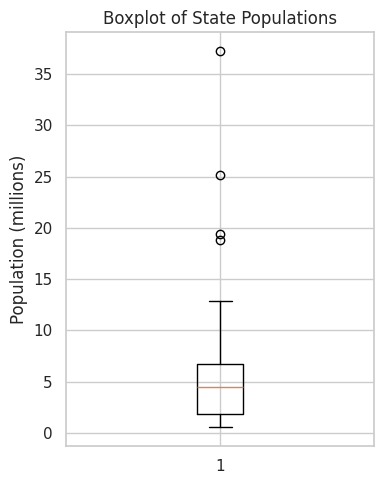

In [8]:
fig, ax = plt.subplots(figsize=(4, 5))
ax.boxplot(state["Population"] / 1_000_000, vert=True)
ax.set_ylabel("Population (millions)")
ax.set_title("Boxplot of State Populations")
plt.tight_layout()
plt.show()

### Interpretasi Boxplot

Boxplot memperlihatkan bahwa sebagian besar negara bagian mempunyai populasi jauh lebih kecil dibanding beberapa negara bagian yang sangat besar. Titik di luar whisker dapat dianggap sebagai observasi ekstrem berdasarkan aturan boxplot yang digunakan.

Hal ini memperlihatkan mengapa mean dapat terdorong oleh outlier dan mengapa median/trimmed mean sering berguna sebagai ukuran yang lebih robust.

## 6. Frequency Table, Histogram, dan Density Plot

### Frequency Table
Membagi rentang nilai menjadi beberapa interval/bin dan menghitung jumlah observasi pada setiap interval.

### Histogram
Memvisualisasikan frekuensi setiap bin.

### Density Plot
Menggambarkan bentuk distribusi sebagai kurva yang lebih halus. Sumbu-y menunjukkan density, bukan jumlah observasi secara langsung.

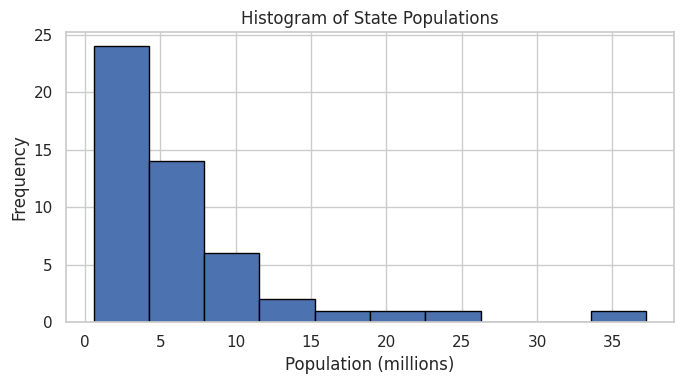

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(state["Population"] / 1_000_000, bins=10, edgecolor="black")
ax.set_xlabel("Population (millions)")
ax.set_ylabel("Frequency")
ax.set_title("Histogram of State Populations")
plt.tight_layout()
plt.show()

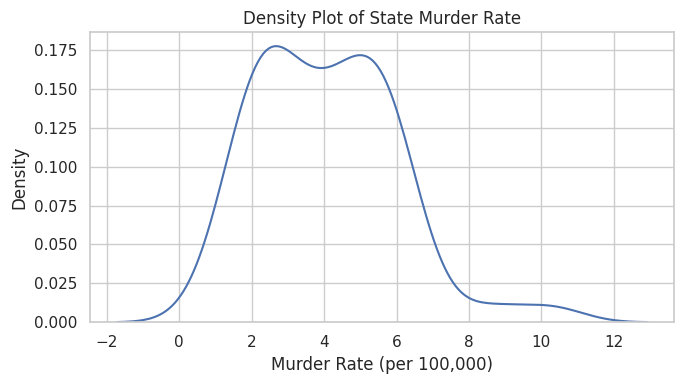

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(state["Murder.Rate"], fill=False, ax=ax)
ax.set_xlabel("Murder Rate (per 100,000)")
ax.set_ylabel("Density")
ax.set_title("Density Plot of State Murder Rate")
plt.tight_layout()
plt.show()

## 7. Binary dan Categorical Data

Data kategorikal tidak selalu cocok diringkas dengan mean. Untuk kategori, proporsi dan frekuensi sering lebih informatif.

Konsep yang dibahas:

- **Mode** — kategori/nilai yang paling sering muncul.
- **Expected value** — rata-rata berbobot berdasarkan probabilitas.
- **Bar chart** — membandingkan frekuensi/proposi kategori.
- **Pie chart** — menampilkan proporsi kategori.

Expected value:

\[
E(X)=\sum_i p_i x_i
\]

In [11]:
dfw = pd.read_csv(get_data("dfw_airline.csv"))
dfw

,Carrier,ATC,Weather,Security,Inbound
0,64263.16,84856.5,11235.42,343.15,118427.82


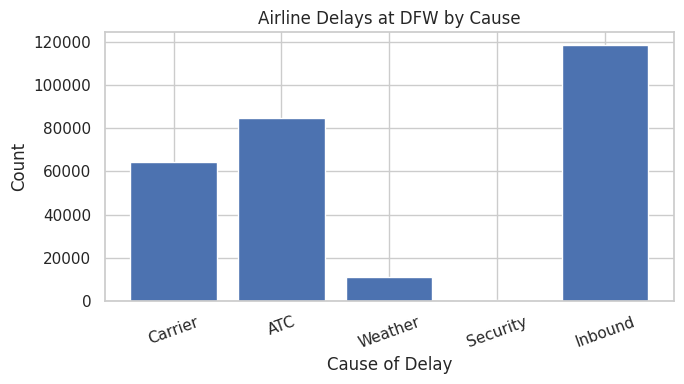

In [12]:
dfw_long = dfw.T.reset_index()
dfw_long.columns = ["Cause", "Count"]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(dfw_long["Cause"], dfw_long["Count"])
ax.set_xlabel("Cause of Delay")
ax.set_ylabel("Count")
ax.set_title("Airline Delays at DFW by Cause")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Interpretasi

Bar chart memudahkan perbandingan penyebab keterlambatan penerbangan. Karena variabel yang ditampilkan adalah kategori, grafik batang lebih sesuai daripada histogram.

Contoh expected value: jika suatu layanan memiliki beberapa harga dengan probabilitas berbeda, nilai harapan dihitung dengan mengalikan setiap harga dengan probabilitasnya lalu menjumlahkannya.

## 8. Correlation

Correlation digunakan untuk mengukur kekuatan dan arah hubungan linear antara dua variabel numerik.

Koefisien Pearson:

\[
r =
\frac{\sum_i(x_i-\bar{x})(y_i-\bar{y})}
{(n-1)s_xs_y}
\]

Rentang:

\[
-1 \le r \le 1
\]

- \(r\) mendekati +1 → hubungan positif kuat,
- \(r\) mendekati -1 → hubungan negatif kuat,
- \(r\) mendekati 0 → tidak ada hubungan linear yang kuat.

**Penting:** correlation tidak dengan sendirinya membuktikan hubungan sebab-akibat.

In [13]:
sp500_sym = pd.read_csv(get_data("sp500_sectors.csv"))
sp500_px = pd.read_csv(get_data("sp500_data.csv.gz"), index_col=0)

# Menentukan saham sektor telecommunications services.
telecom_symbols = sp500_sym.loc[
    sp500_sym["sector"] == "telecommunications_services", "symbol"
]

telecom = sp500_px.loc[
    sp500_px.index >= "2012-07-01",
    telecom_symbols
]

telecom.corr()

,T,CTL,FTR,VZ,LVLT
T,1.000000,0.474683,0.327767,0.677612,0.278626
CTL,0.474683,1.000000,0.419757,0.416604,0.286665
FTR,0.327767,0.419757,1.000000,0.287386,0.260068
VZ,0.677612,0.416604,0.287386,1.000000,0.242199
LVLT,0.278626,0.286665,0.260068,0.242199,1.000000


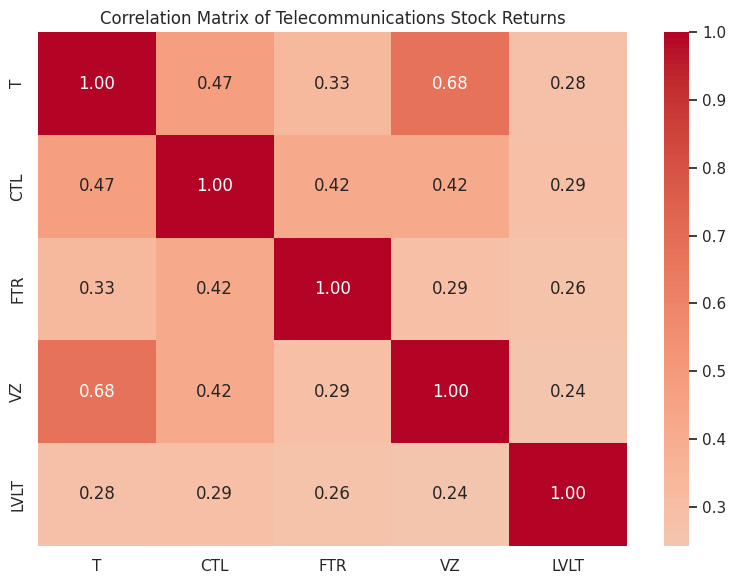

In [14]:
plt.figure(figsize=(8, 6))
sns.heatmap(telecom.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Telecommunications Stock Returns")
plt.tight_layout()
plt.show()

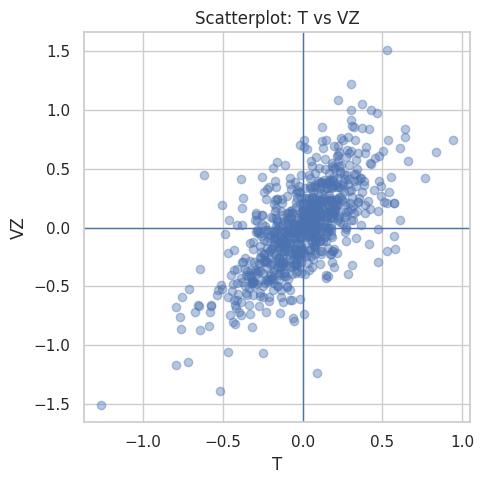

In [15]:
# Scatterplot untuk dua saham telekomunikasi yang tersedia.
available = [c for c in ["T", "VZ"] if c in telecom.columns]
if len(available) == 2:
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(telecom[available[0]], telecom[available[1]], alpha=0.4)
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    ax.set_xlabel(available[0])
    ax.set_ylabel(available[1])
    ax.set_title(f"Scatterplot: {available[0]} vs {available[1]}")
    plt.tight_layout()
    plt.show()
else:
    print("Kolom T dan VZ tidak tersedia pada versi data yang digunakan.")

## 9. Exploring Two or More Variables

Untuk dua variabel numerik dengan jumlah observasi besar, scatterplot dapat menjadi terlalu padat. Chapter memperkenalkan:

- hexagonal binning,
- contour plot,
- contingency table,
- boxplot berdasarkan kategori,
- violin plot,
- faceting/conditioning untuk melihat pola berdasarkan kelompok.

Tujuannya adalah melihat hubungan antarvariabel tanpa kehilangan struktur distribusi.

In [16]:
kc_tax = pd.read_csv(get_data("kc_tax.csv.gz"))

kc_tax0 = kc_tax.loc[
    (kc_tax["TaxAssessedValue"] < 750000) &
    (kc_tax["SqFtTotLiving"] > 100) &
    (kc_tax["SqFtTotLiving"] < 3500)
].copy()

print("Filtered shape:", kc_tax0.shape)
kc_tax0.head()

Filtered shape: (432693, 3)


,TaxAssessedValue,SqFtTotLiving,ZipCode
1,206000.0,1870,98002.0
2,303000.0,1530,98166.0
3,361000.0,2000,98108.0
4,459000.0,3150,98108.0
5,223000.0,1570,98032.0


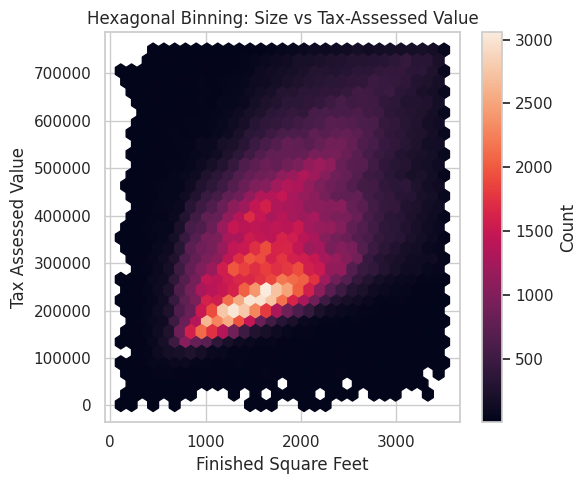

In [17]:
fig, ax = plt.subplots(figsize=(6, 5))
hb = ax.hexbin(
    kc_tax0["SqFtTotLiving"],
    kc_tax0["TaxAssessedValue"],
    gridsize=30,
    mincnt=1
)
ax.set_xlabel("Finished Square Feet")
ax.set_ylabel("Tax Assessed Value")
ax.set_title("Hexagonal Binning: Size vs Tax-Assessed Value")
fig.colorbar(hb, ax=ax, label="Count")
plt.tight_layout()
plt.show()

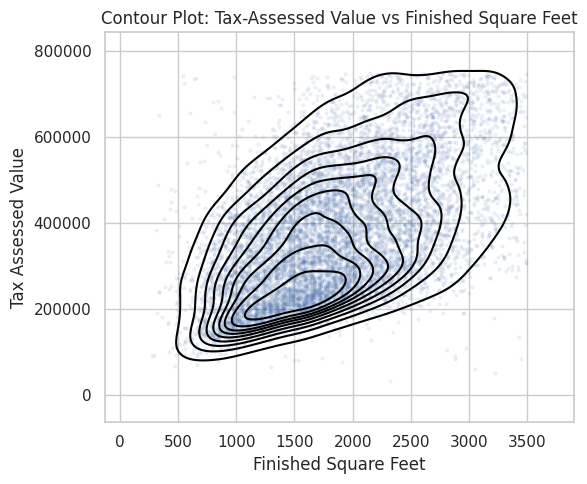

In [18]:
# Contour/KDE plot menggunakan sampel agar proses lebih ringan.
sample = kc_tax0.sample(min(10000, len(kc_tax0)), random_state=42)

fig, ax = plt.subplots(figsize=(6, 5))
sns.kdeplot(
    data=sample,
    x="SqFtTotLiving",
    y="TaxAssessedValue",
    levels=10,
    color="black",
    ax=ax
)
ax.scatter(
    sample["SqFtTotLiving"],
    sample["TaxAssessedValue"],
    s=4,
    alpha=0.08
)
ax.set_xlabel("Finished Square Feet")
ax.set_ylabel("Tax Assessed Value")
ax.set_title("Contour Plot: Tax-Assessed Value vs Finished Square Feet")
plt.tight_layout()
plt.show()

## 10. Contingency Table

Contingency table digunakan untuk melihat hubungan antara dua variabel kategorikal dengan menghitung jumlah observasi pada setiap kombinasi kategori.

Contoh pada chapter menggunakan status pinjaman dan grade pinjaman.

In [19]:
lc_loans = pd.read_csv(get_data("lc_loans.csv"))
lc_loans.head()

,status,grade
0,Fully Paid,B
1,Charged Off,C
2,Fully Paid,C
3,Fully Paid,C
4,Current,B


In [20]:
loan_table = pd.crosstab(
    lc_loans["grade"],
    lc_loans["status"],
    margins=True
)

loan_table

status,Charged Off,Current,Fully Paid,Late,All
grade,,,,,
A,1562,50051,20408,469,72490
B,5302,93852,31160,2056,132370
C,6023,88928,23147,2777,120875
D,5007,53281,13681,2308,74277
E,2842,24639,5949,1374,34804
F,1526,8444,2328,606,12904
G,409,1990,643,199,3241
All,22671,321185,97316,9789,450961


### Interpretasi

Contingency table memungkinkan kita membandingkan status pinjaman pada setiap grade. Untuk analisis lanjutan, tabel jumlah dapat diubah menjadi proporsi per baris agar distribusi status di dalam setiap grade lebih mudah dibandingkan.

In [21]:
row_pct = pd.crosstab(
    lc_loans["grade"],
    lc_loans["status"],
    normalize="index"
)

row_pct

status,Charged Off,Current,Fully Paid,Late
grade,,,,
A,0.021548,0.690454,0.281528,0.006470
B,0.040054,0.709013,0.235401,0.015532
C,0.049828,0.735702,0.191495,0.022974
D,0.067410,0.717328,0.184189,0.031073
E,0.081657,0.707936,0.170929,0.039478
F,0.118258,0.654371,0.180409,0.046962
G,0.126196,0.614008,0.198396,0.061401


## 11. Categorical vs Numeric Data

Boxplot dan violin plot dapat digunakan untuk membandingkan distribusi variabel numerik pada beberapa kategori.

Boxplot menampilkan ringkasan kuartil dan outlier. Violin plot menambahkan informasi bentuk density sehingga variasi distribusi di dalam setiap kategori dapat terlihat lebih jelas.

In [22]:
airline_stats = pd.read_csv(get_data("airline_stats.csv"))
airline_stats.head()

,pct_carrier_delay,pct_atc_delay,pct_weather_delay,airline
0,8.153226,1.971774,0.762097,American
1,5.959924,3.706107,1.585878,American
2,7.157270,2.706231,2.026706,American
3,12.100000,11.033333,0.000000,American
4,7.333333,3.365591,1.774194,American


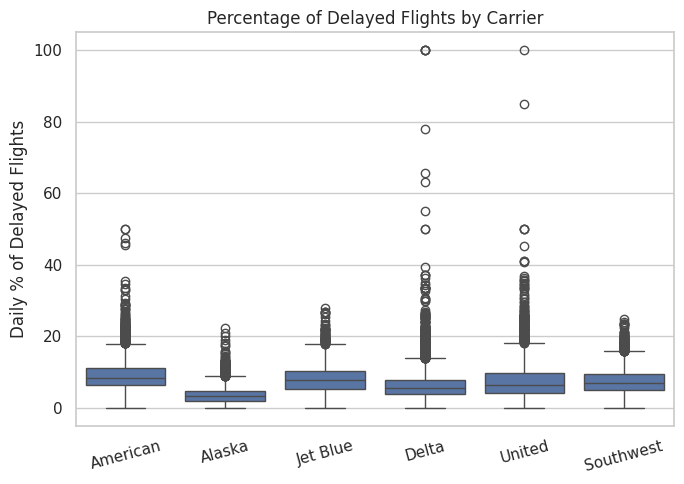

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(
    data=airline_stats,
    x="airline",
    y="pct_carrier_delay",
    ax=ax
)
ax.set_xlabel("")
ax.set_ylabel("Daily % of Delayed Flights")
ax.set_title("Percentage of Delayed Flights by Carrier")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

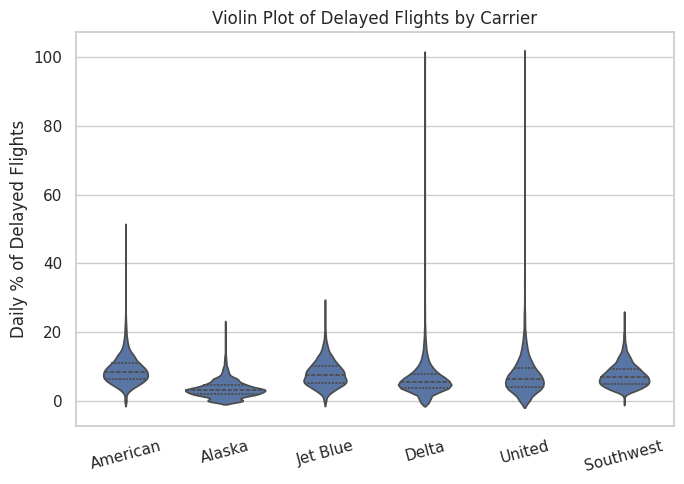

In [24]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.violinplot(
    data=airline_stats,
    x="airline",
    y="pct_carrier_delay",
    inner="quartile",
    ax=ax
)
ax.set_xlabel("")
ax.set_ylabel("Daily % of Delayed Flights")
ax.set_title("Violin Plot of Delayed Flights by Carrier")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 12. Visualizing Multiple Variables

Ketika dua variabel sudah dipahami, kategori ketiga dapat digunakan sebagai **conditioning variable** atau pembeda kelompok.

Pada contoh perumahan, hubungan `SqFtTotLiving` dan `TaxAssessedValue` dapat diperiksa untuk beberapa ZIP code. Pendekatan ini membantu melihat apakah pola hubungan numerik berubah antar kelompok.

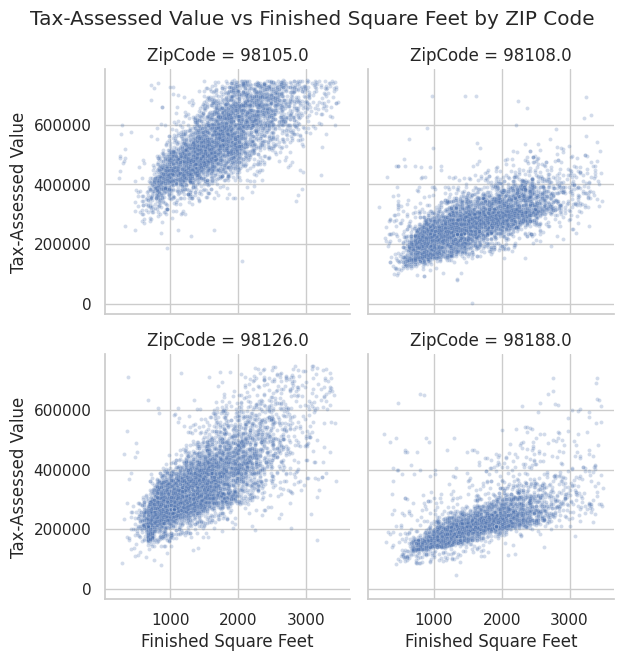

In [25]:
zip_codes = [98188, 98105, 98108, 98126]
subset = kc_tax0.loc[kc_tax0["ZipCode"].isin(zip_codes)].copy()

g = sns.FacetGrid(
    subset,
    col="ZipCode",
    col_wrap=2,
    height=3.2,
    sharex=True,
    sharey=True
)
g.map_dataframe(
    sns.scatterplot,
    x="SqFtTotLiving",
    y="TaxAssessedValue",
    s=8,
    alpha=0.25
)
g.set_axis_labels("Finished Square Feet", "Tax-Assessed Value")
g.fig.suptitle("Tax-Assessed Value vs Finished Square Feet by ZIP Code", y=1.03)
plt.show()

# 13. Analisis dan Kesimpulan Chapter 1

Berdasarkan reproduksi dan pembahasan Chapter 1, beberapa hal utama yang dipelajari adalah:

1. **EDA dilakukan sebelum pemodelan** untuk memahami data dan menemukan pola, anomali, serta karakteristik penting.
2. **Mean, median, dan trimmed mean** digunakan untuk menggambarkan lokasi/pusat data dengan tingkat sensitivitas yang berbeda terhadap outlier.
3. **Standard deviation, MAD, dan IQR** digunakan untuk menggambarkan penyebaran data.
4. **Percentile dan boxplot** membantu melihat posisi data dan mendeteksi nilai ekstrem.
5. **Histogram dan density plot** membantu memahami bentuk distribusi.
6. **Bar chart** cocok untuk data kategorikal, sedangkan histogram cocok untuk data numerik.
7. **Correlation dan scatterplot** membantu mengevaluasi hubungan antarvariabel numerik.
8. **Hexbin dan contour plot** lebih berguna ketika jumlah titik sangat banyak dan scatterplot menjadi terlalu padat.
9. **Contingency table** digunakan untuk dua variabel kategorikal.
10. **Boxplot dan violin plot** membantu membandingkan variabel numerik berdasarkan kategori.

### Kesimpulan
EDA bukan sekadar membuat grafik. EDA merupakan proses sistematis untuk memahami struktur data, memilih ukuran statistik yang tepat, menemukan pola dan outlier, serta membangun dasar yang lebih baik sebelum melakukan analisis statistik atau Machine Learning.